# Part 2. Time series preprocessing - exercise
We are going to practice what we have learnt in preprocessing and analysis lessons. Using a challenge dataset from Kaggle we are going to preprocess the dataset for a forecasting task. We may not know what forecasting is yet, but we have all the tools available to make the preprocessing.

## Dataset
You can find the target dataset at the [kaggle electric-power-consumption-data-set](https://www.kaggle.com/datasets/uciml/electric-power-consumption-data-set). The dataset contains measures of electic power consumption in a single household. Try to infer as much information from the data by yourself even before downloading the dataset.

## Objective
Your task is to prepare a dataframe and save it as a .csv file. The dataframe must have rows with sliding windows for all the variables and the window size is w=5min. Thus, there must be a column for the timestamp at $t$ and a column with each variable $Z^{(i)}$ where $Z^{(i)}=\{Z^{(i)}_t, Z^{(i)}_{t-1}, Z^{(i)}_{t-2}, ..., Z^{(i)}_{t-w}\}$ and $i$ is the identifier of the variable. Preprocess the dataset as best as you can using the techniques learned during the previous lesson. Begin with:
- Plot the variables, including advanced plots
- Perform a simple EDA

And keep an eye out for:
- Missing data
- Magnitudes of the variables
- Stationarity
- Seasonality
- Trend

Use whatever means necessary to achieve a high-quality preprocessing!

# 🚚 Import data

In [51]:
import kagglehub
import os

# Download latest version

# Ruta personalizada
os.environ["KAGGLEHUB_CACHE"] = "../data"

# Descargar la última versión
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path)

Path to dataset files: ../data/datasets/uciml/electric-power-consumption-data-set/versions/1


## Load data

In [52]:
import polars as pl
df = pl.read_csv(path+"/household_power_consumption.txt", separator=";", null_values="?")
df.head()


Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
str,str,f64,f64,f64,f64,f64,f64,f64
"""16/12/2006""","""17:24:00""",4.216,0.418,234.84,18.4,0.0,1.0,17.0
"""16/12/2006""","""17:25:00""",5.36,0.436,233.63,23.0,0.0,1.0,16.0
"""16/12/2006""","""17:26:00""",5.374,0.498,233.29,23.0,0.0,2.0,17.0
"""16/12/2006""","""17:27:00""",5.388,0.502,233.74,23.0,0.0,1.0,17.0
"""16/12/2006""","""17:28:00""",3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [53]:
df.shape

(2075259, 9)

## 📆 Gestion de fechas

In [54]:
from datetime import datetime
df = df.with_columns(
    # 1. Combinar Date y Time como String, 
    # 2. Convertir a Datetime,
    # 3. Extraer el timestamp (segundos desde la época)
    date_timestamp = (
        (pl.col("Date") + " " + pl.col("Time"))
        .str.to_datetime(format="%d/%m/%Y %H:%M:%S")
        .dt.timestamp("ms") // 1000
    )
)

df.head()


Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,date_timestamp
str,str,f64,f64,f64,f64,f64,f64,f64,i64
"""16/12/2006""","""17:24:00""",4.216,0.418,234.84,18.4,0.0,1.0,17.0,1166289840
"""16/12/2006""","""17:25:00""",5.36,0.436,233.63,23.0,0.0,1.0,16.0,1166289900
"""16/12/2006""","""17:26:00""",5.374,0.498,233.29,23.0,0.0,2.0,17.0,1166289960
"""16/12/2006""","""17:27:00""",5.388,0.502,233.74,23.0,0.0,1.0,17.0,1166290020
"""16/12/2006""","""17:28:00""",3.666,0.528,235.68,15.8,0.0,1.0,17.0,1166290080


In [55]:
df = df.drop(["Date", "Time"])
df.head()

Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,date_timestamp
f64,f64,f64,f64,f64,f64,f64,i64
4.216,0.418,234.84,18.4,0.0,1.0,17.0,1166289840
5.36,0.436,233.63,23.0,0.0,1.0,16.0,1166289900
5.374,0.498,233.29,23.0,0.0,2.0,17.0,1166289960
5.388,0.502,233.74,23.0,0.0,1.0,17.0,1166290020
3.666,0.528,235.68,15.8,0.0,1.0,17.0,1166290080


In [56]:
t_min = df.select(pl.col("date_timestamp").min()).item()
t_max = df.select(pl.col("date_timestamp").max()).item()

print(f"Inicio: {datetime.fromtimestamp(t_min)}")
print(f"Fin:    {datetime.fromtimestamp(t_max)}")

Inicio: 2006-12-16 18:24:00
Fin:    2010-11-26 22:02:00


# 🔎 EDA

## 🔢 NPlot by column type

In [57]:
import polars.selectors as cs
# Polars feature selectiom
numeric_data_pl = df.select(cs.numeric())
categorical_data_pl = df.select(cs.string())
print(f"{numeric_data_pl=}")
print(f"{categorical_data_pl=}")



numeric_data_pl=shape: (2_075_259, 8)
┌────────────┬────────────┬─────────┬────────────┬────────────┬────────────┬───────────┬───────────┐
│ Global_act ┆ Global_rea ┆ Voltage ┆ Global_int ┆ Sub_meteri ┆ Sub_meteri ┆ Sub_meter ┆ date_time │
│ ive_power  ┆ ctive_powe ┆ ---     ┆ ensity     ┆ ng_1       ┆ ng_2       ┆ ing_3     ┆ stamp     │
│ ---        ┆ r          ┆ f64     ┆ ---        ┆ ---        ┆ ---        ┆ ---       ┆ ---       │
│ f64        ┆ ---        ┆         ┆ f64        ┆ f64        ┆ f64        ┆ f64       ┆ i64       │
│            ┆ f64        ┆         ┆            ┆            ┆            ┆           ┆           │
╞════════════╪════════════╪═════════╪════════════╪════════════╪════════════╪═══════════╪═══════════╡
│ 4.216      ┆ 0.418      ┆ 234.84  ┆ 18.4       ┆ 0.0        ┆ 1.0        ┆ 17.0      ┆ 116628984 │
│            ┆            ┆         ┆            ┆            ┆            ┆           ┆ 0         │
│ 5.36       ┆ 0.436      ┆ 233.63  ┆ 23.0       ┆ 0.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- SECCIÓN NUMÉRICA (Violin Plots) ---
num_cols = df.select(cs.numeric()).exclude("date_timestamp").columns
n_num = len(num_cols)
fig_num, axes_num = plt.subplots(nrows=(n_num + 1) // 2, ncols=2, figsize=(14, 5 * ((n_num + 1) // 2)))
axes_num = axes_num.flatten()

print("Generando plots numéricos con estadísticas...")
for i, col in enumerate(num_cols):
    # Calculamos estadísticas sobre el TOTAL para máxima precisión
    stats = numeric_data_pl.select([
        pl.col(col).min().alias("min"),
        pl.col(col).max().alias("max"),
        pl.col(col).mean().alias("mean"),
        pl.col(col).median().alias("median")
    ]).to_dicts()[0]

    # Datos para el violín (sample para velocidad)
    data_np = numeric_data_pl.select(col).drop_nulls().sample(100_000).to_numpy().ravel()
    
    # Plot
    sns.violinplot(y=data_np, ax=axes_num[i], color="skyblue", inner="quartile")
    
    # Insertar texto con los valores
    textstr = '\n'.join((
        f'Máx: {stats["max"]:.2f}',
        f'Mín: {stats["min"]:.2f}',
        f'Media: {stats["mean"]:.2f}',
        f'Mediana: {stats["median"]:.2f}'
    ))
    
    # Posicionamos el texto en la esquina superior derecha del eje
    axes_num[i].text(0.95, 0.95, textstr, transform=axes_num[i].transAxes, fontsize=10,
                     verticalalignment='top', horizontalalignment='right',
                     bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    axes_num[i].set_ylabel("Valor")
    axes_num[i].set_title(f"Distribución: {col}")

# Eliminar ejes sobrantes
for j in range(i + 1, len(axes_num)):
    fig_num.delaxes(axes_num[j])

fig_num.tight_layout()
plt.show()

AttributeError: 'DataFrame' object has no attribute 'exclude'

## 📊 Plot

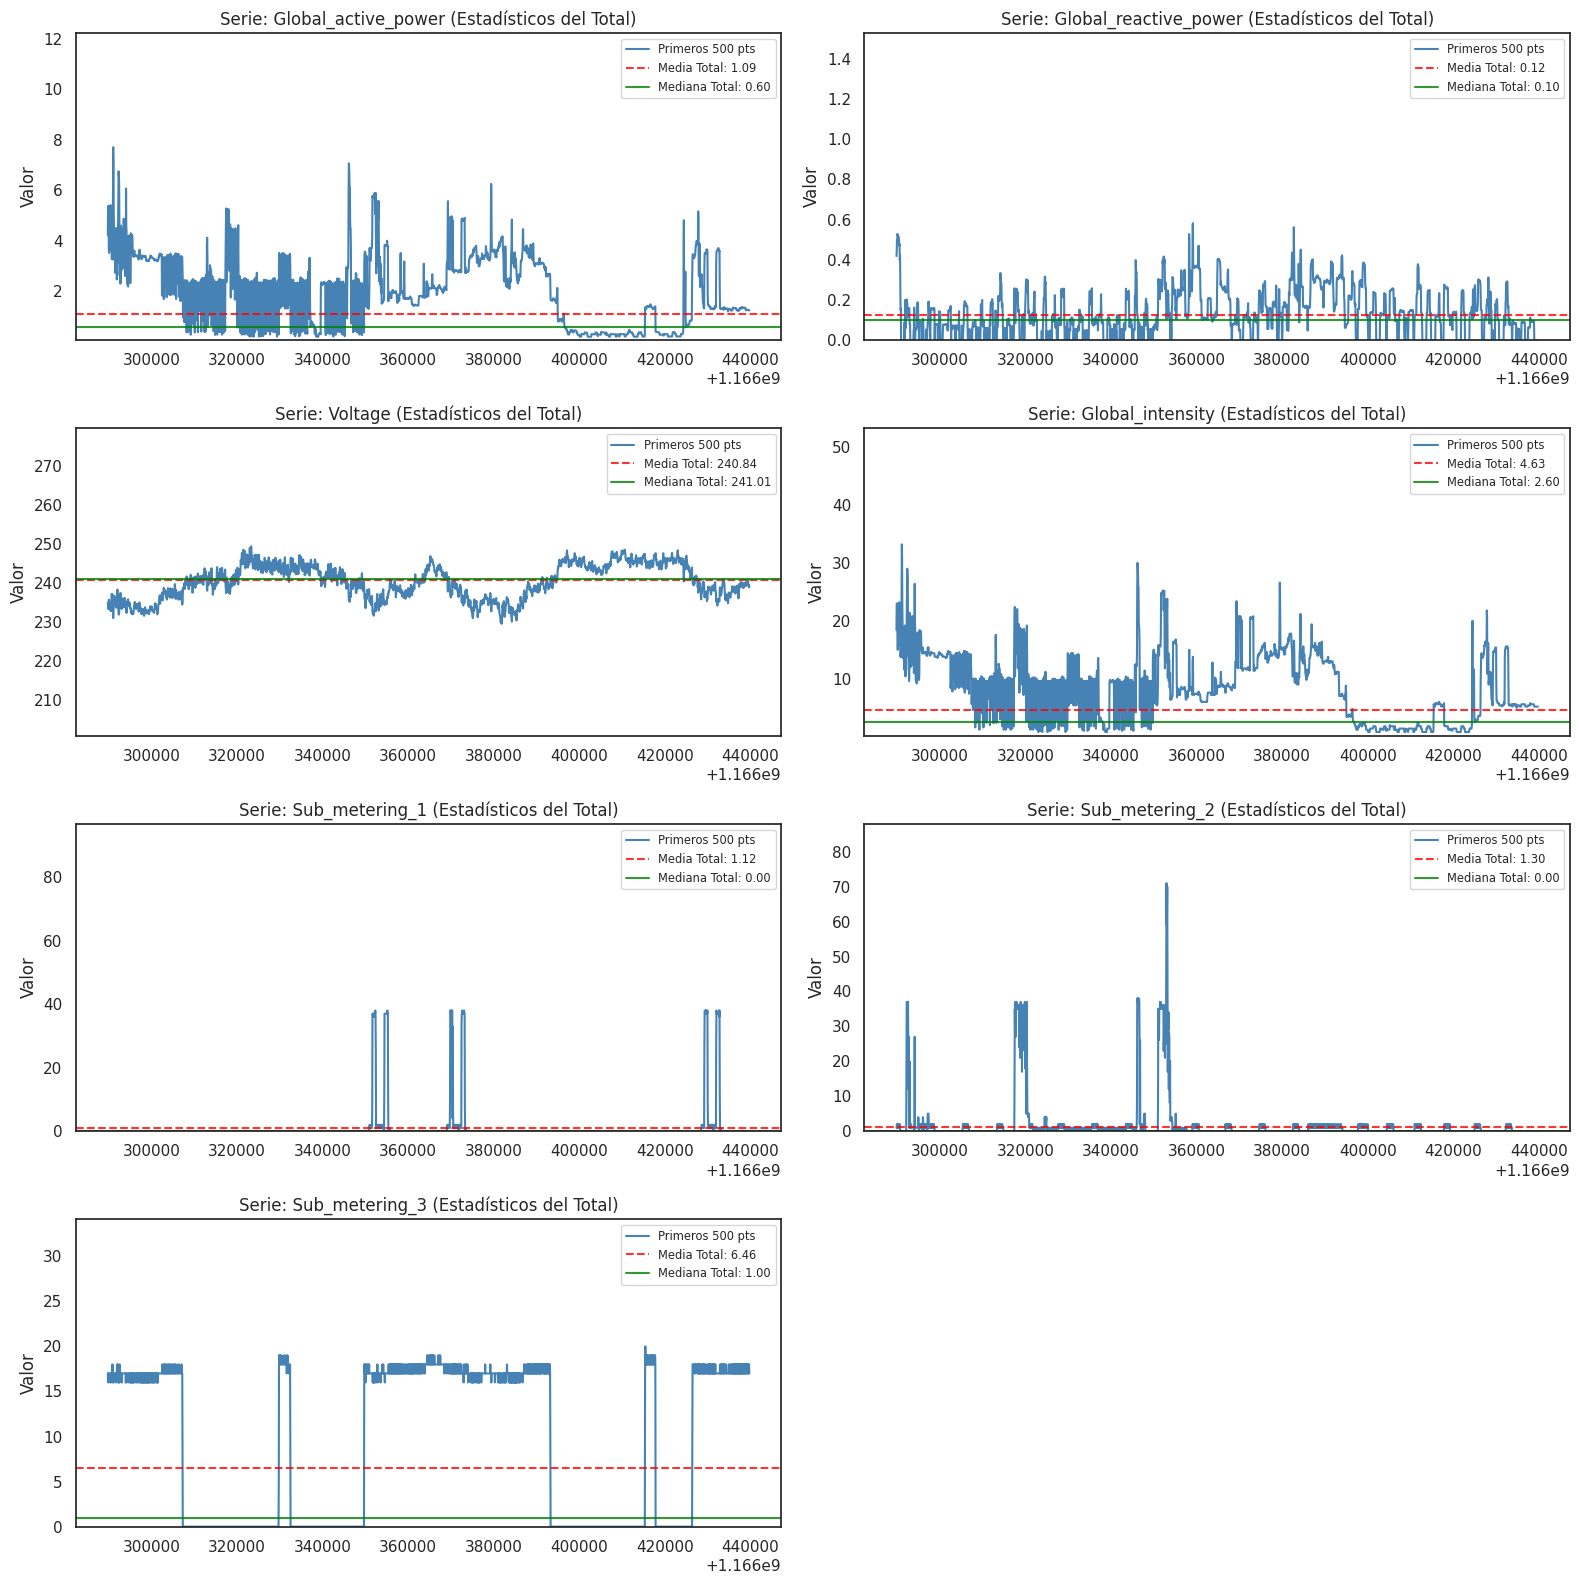

In [ ]:
# Definir columnas a procesar
cols_to_plot = [c for c in numeric_data_pl.columns if c != "date_timestamp"]
n_cols = len(cols_to_plot)
# Tomar los primeros 500 puntos para la visualización
df_sample = numeric_data_pl.head(2_500)
x_sample = df_sample.select("date_timestamp").to_numpy().ravel()

# Configuración del mosaico
fig, axes = plt.subplots(nrows=(n_cols + 1) // 2, ncols=2, figsize=(16, 4 * ((n_cols + 1) // 2)))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    # --- CÁLCULOS SOBRE EL TOTAL (numeric_data_pl) ---
    stats = numeric_data_pl.select([
        pl.col(col).max().alias("max"),
        pl.col(col).min().alias("min"),
        pl.col(col).mean().alias("mean"),
        pl.col(col).median().alias("median")
    ]).to_dicts()[0]
    
    # --- DATOS PARA EL PLOT (df_sample) ---
    y_sample = df_sample.select(col).to_numpy().ravel()

    # Plot de la serie (primeros 500 puntos)
    sns.lineplot(x=x_sample, y=y_sample, ax=axes[i], color='steelblue', label='Primeros 500 pts')
    
    # Líneas horizontales basadas en el TOTAL
    axes[i].axhline(stats["mean"], color='red', linestyle='--', alpha=0.8, label=f'Media Total: {stats["mean"]:.2f}')
    axes[i].axhline(stats["median"], color='green', linestyle='-', alpha=0.8, label=f'Mediana Total: {stats["median"]:.2f}')
    
    # Límites máximos y mínimos del TOTAL (como referencia en el eje Y)
    axes[i].set_ylim(stats["min"] * 0.9, stats["max"] * 1.1)
    
    axes[i].set_title(f"Serie: {col} (Estadísticos del Total)")
    axes[i].set_ylabel("Valor")
    axes[i].legend(loc='upper right', fontsize='x-small')

# Limpiar ejes sobrantes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## 🫗 Missing values:

In [ ]:
# Obtener el número total de filas
total_rows = len(df)
# Calcular nulos con porcentaje
missing = (
    df.select(pl.all().is_null().sum())
    .unpivot(variable_name="column", value_name="missing_count")
    .with_columns(
        percentage = ((pl.col("missing_count") / total_rows) * 100).round(2).cast(pl.String) + "%"
    )
    .filter(pl.col("missing_count") > 0)
)

# Columnas estáticas (un solo valor único)
static = (
    df.select(pl.all().n_unique())
    .unpivot(variable_name="column", value_name="unique_count")
    .filter(pl.col("unique_count") == 1)
)

print(f"Total de registros: {total_rows}")
print("-" * 30)
print("Missing columns:")
print(missing)

print("\nStatic columns:")
print(static)

Total de registros: 2075259
------------------------------
Missing columns:
shape: (7, 3)
┌───────────────────────┬───────────────┬────────────┐
│ column                ┆ missing_count ┆ percentage │
│ ---                   ┆ ---           ┆ ---        │
│ str                   ┆ u32           ┆ str        │
╞═══════════════════════╪═══════════════╪════════════╡
│ Global_active_power   ┆ 25979         ┆ 1.25%      │
│ Global_reactive_power ┆ 25979         ┆ 1.25%      │
│ Voltage               ┆ 25979         ┆ 1.25%      │
│ Global_intensity      ┆ 25979         ┆ 1.25%      │
│ Sub_metering_1        ┆ 25979         ┆ 1.25%      │
│ Sub_metering_2        ┆ 25979         ┆ 1.25%      │
│ Sub_metering_3        ┆ 25979         ┆ 1.25%      │
└───────────────────────┴───────────────┴────────────┘

Static columns:
shape: (0, 2)
┌────────┬──────────────┐
│ column ┆ unique_count │
│ ---    ┆ ---          │
│ str    ┆ u32          │
╞════════╪══════════════╡
└────────┴──────────────┘


# 🌇 Trend, seasonality

## 📊 Seasonality plot:

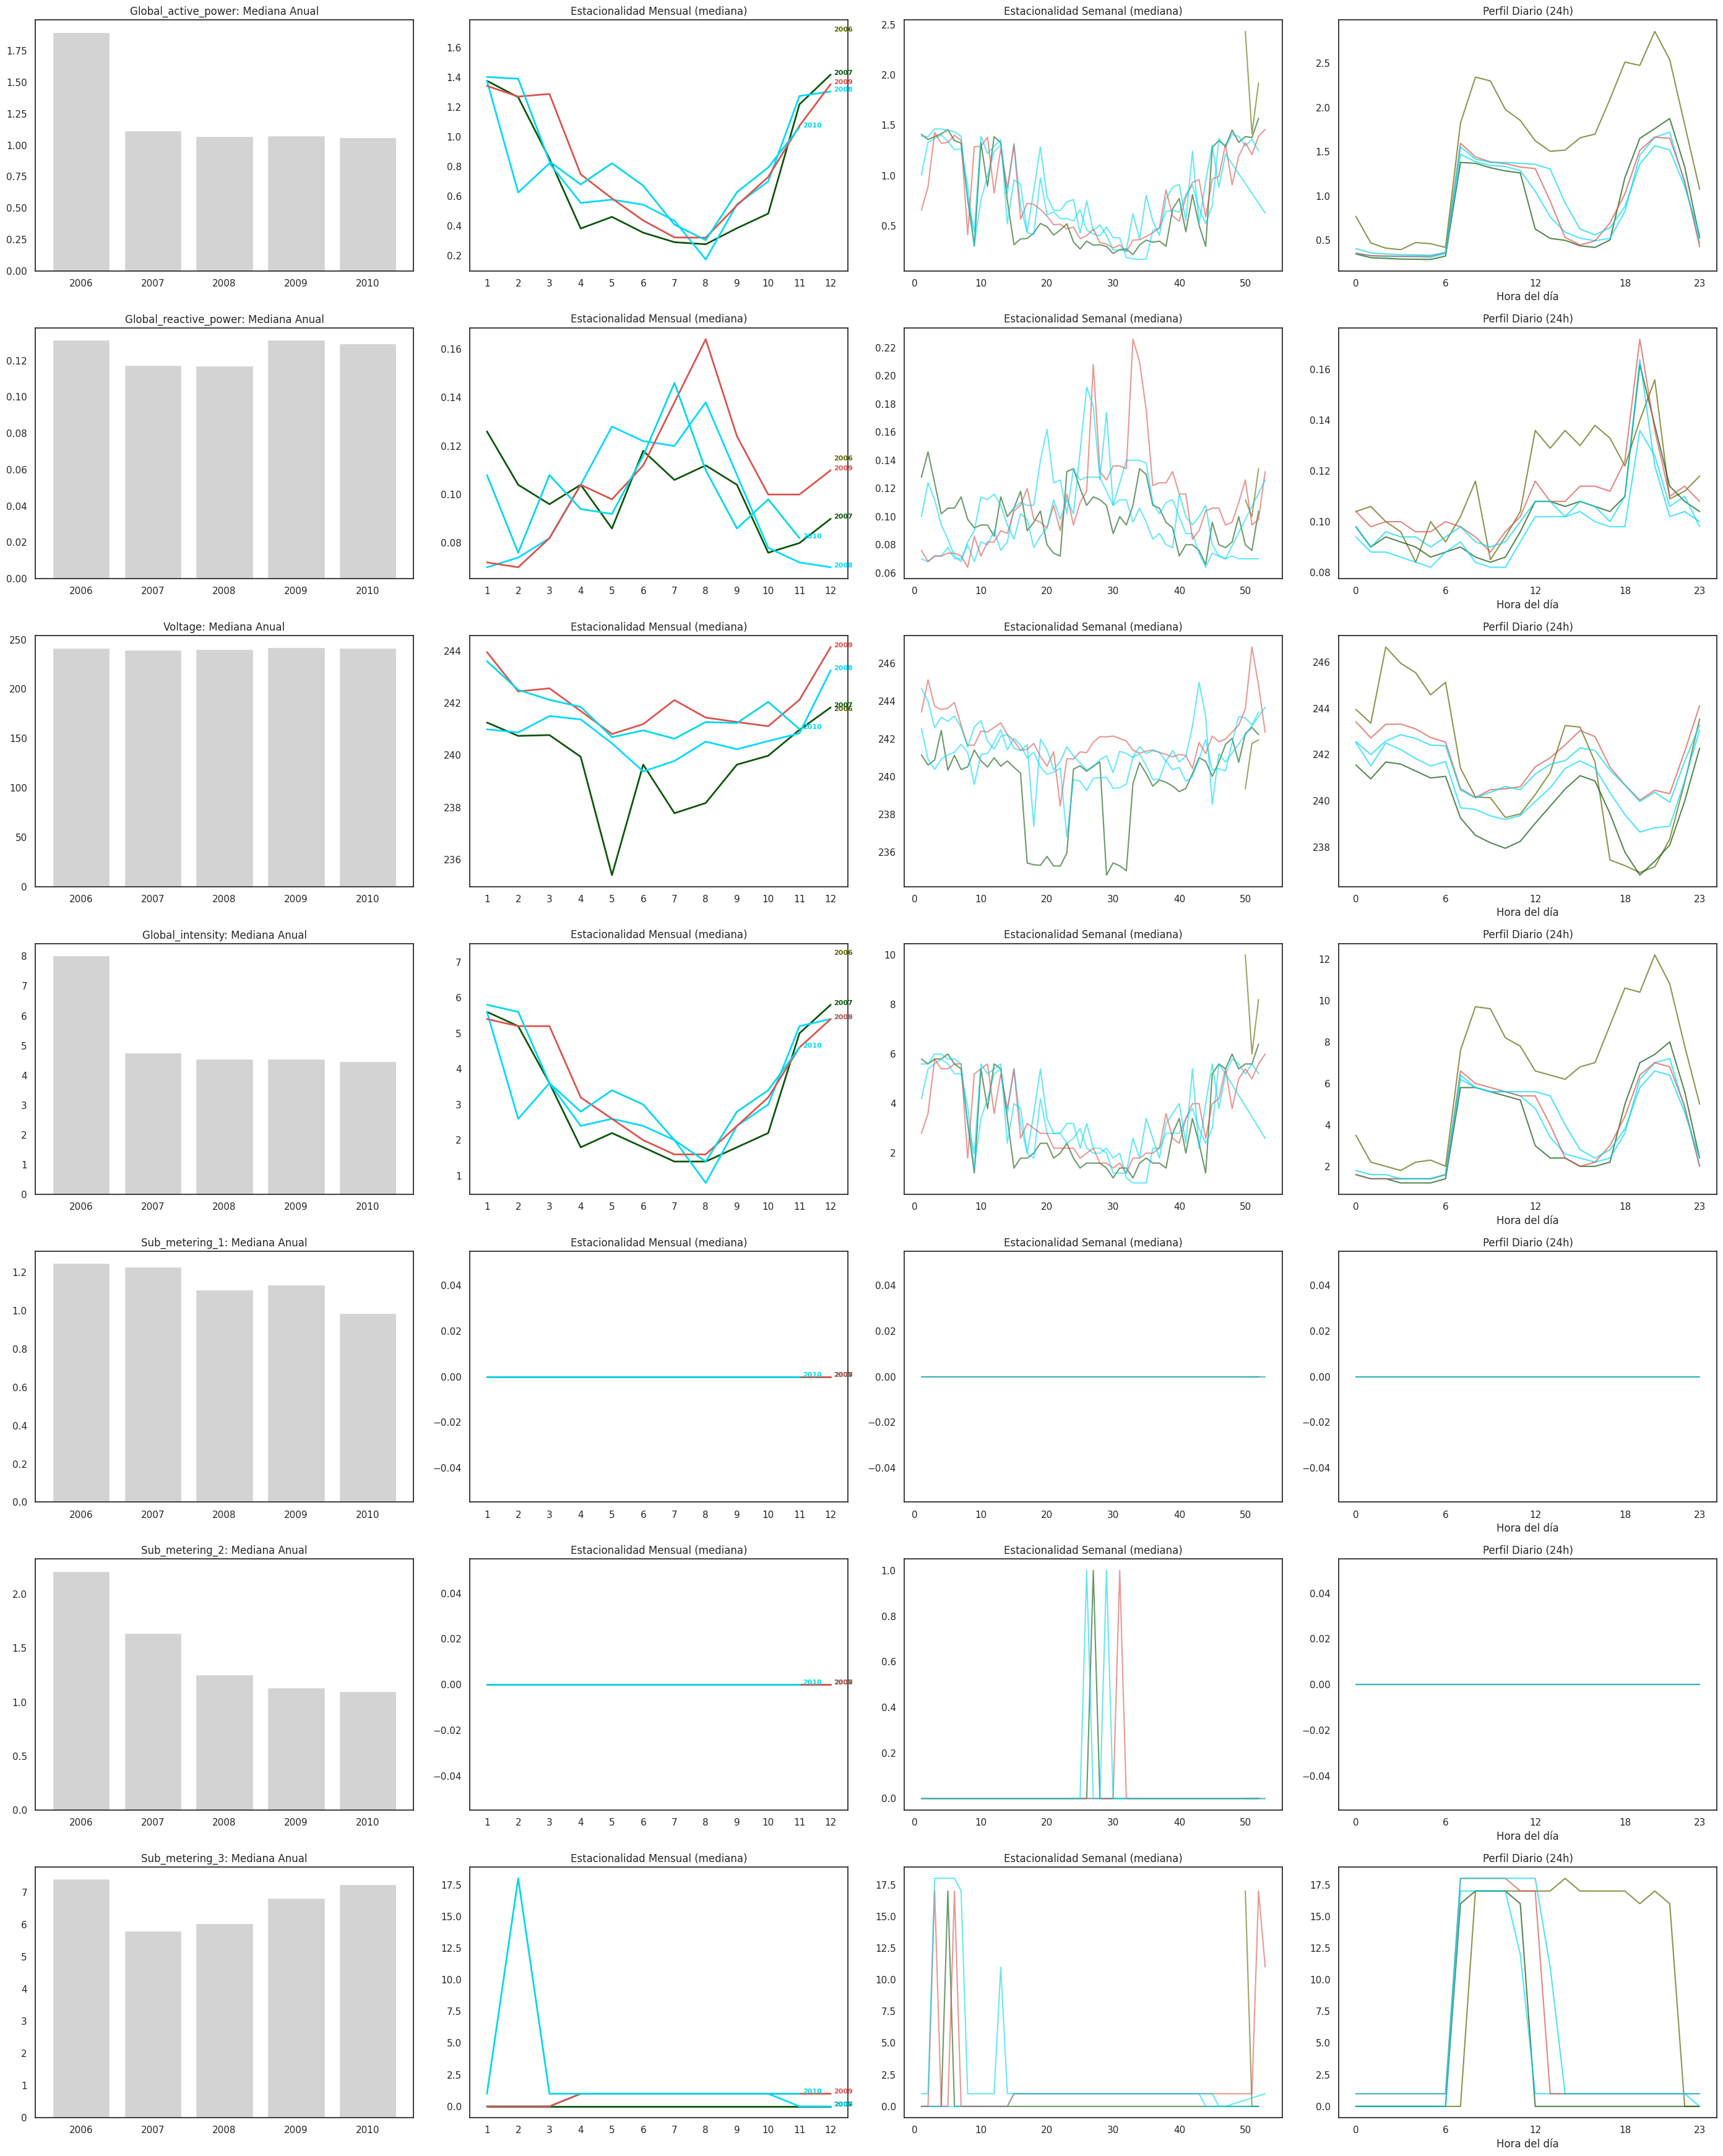

In [39]:
import matplotlib as mpl


# 1. Preparar las columnas temporales extra (Día y Hora)
df = df.with_columns(
    dt = pl.from_epoch(pl.col("date_timestamp"), time_unit="s")
).with_columns(
    year = pl.col("dt").dt.year(),
    month = pl.col("dt").dt.month(),
    week = pl.col("dt").dt.week(),
    hour = pl.col("dt").dt.hour()
)

variables = [c for c in numeric_data_pl.columns if c != "date_timestamp"]
np.random.seed(42)
years = df["year"].unique().sort().to_numpy()
colors = np.random.choice(list(mpl.colors.XKCD_COLORS.keys()), len(years), replace=False)

# 4 Columnas: Año, Mes, Semana, Día (Hora)
fig, axes = plt.subplots(nrows=len(variables), ncols=4, figsize=(28, 5 * len(variables)))

for i, var in enumerate(variables):

    # --- COLUMNA 1: POR AÑO ---
    df_year = df.group_by("year").agg(pl.col(var).mean()).sort("year")
    axes[i, 0].bar(df_year["year"].to_numpy(), df_year[var].to_numpy(), color="lightgray")
    axes[i, 0].set_title(f"{var}: Mediana Anual")

    
    # --- COLUMNA 2: MENSUAL (Seasonal) ---
    ax_m = axes[i, 1]
    df_month = df.group_by(["year", "month"]).agg(pl.col(var).median()).sort(["year", "month"])
    for j, y in enumerate(years):
        data_y = df_month.filter(pl.col("year") == y)
        if not data_y.is_empty():
            x, y_val = data_y["month"].to_numpy(), data_y[var].to_numpy()
            ax_m.plot(x, y_val, color=colors[j], label=y, linewidth=2)
            ax_m.text(x[-1] + 0.1, y_val[-1], str(y), color=colors[j], fontsize=8, fontweight='bold')
    ax_m.set_title("Estacionalidad Mensual (mediana)")

    ax_m.set_xticks(range(1, 13))

    # --- COLUMNA 3: SEMANAL (Seasonal) ---
    ax_w = axes[i, 2]
    df_week = df.group_by(["year", "week"]).agg(pl.col(var).median()).sort(["year", "week"])
    for j, y in enumerate(years):
        data_y = df_week.filter(pl.col("year") == y)
        if not data_y.is_empty():
            ax_w.plot(data_y["week"].to_numpy(), data_y[var].to_numpy(), color=colors[j], alpha=0.6)
    ax_w.set_title("Estacionalidad Semanal (mediana)")


    # --- COLUMNA 4: DIARIA (Por Hora) ---
    ax_d = axes[i, 3]
    df_hour = df.group_by(["year", "hour"]).agg(pl.col(var).median()).sort(["year", "hour"])
    for j, y in enumerate(years):
        data_y = df_hour.filter(pl.col("year") == y)
        if not data_y.is_empty():
            ax_d.plot(data_y["hour"].to_numpy(), data_y[var].to_numpy(), color=colors[j], alpha=0.7)
    ax_d.set_title("Perfil Diario (24h)")
    ax_d.set_xlabel("Hora del día")
    ax_d.set_xticks([0, 6, 12, 18, 23])

plt.tight_layout()
plt.show()

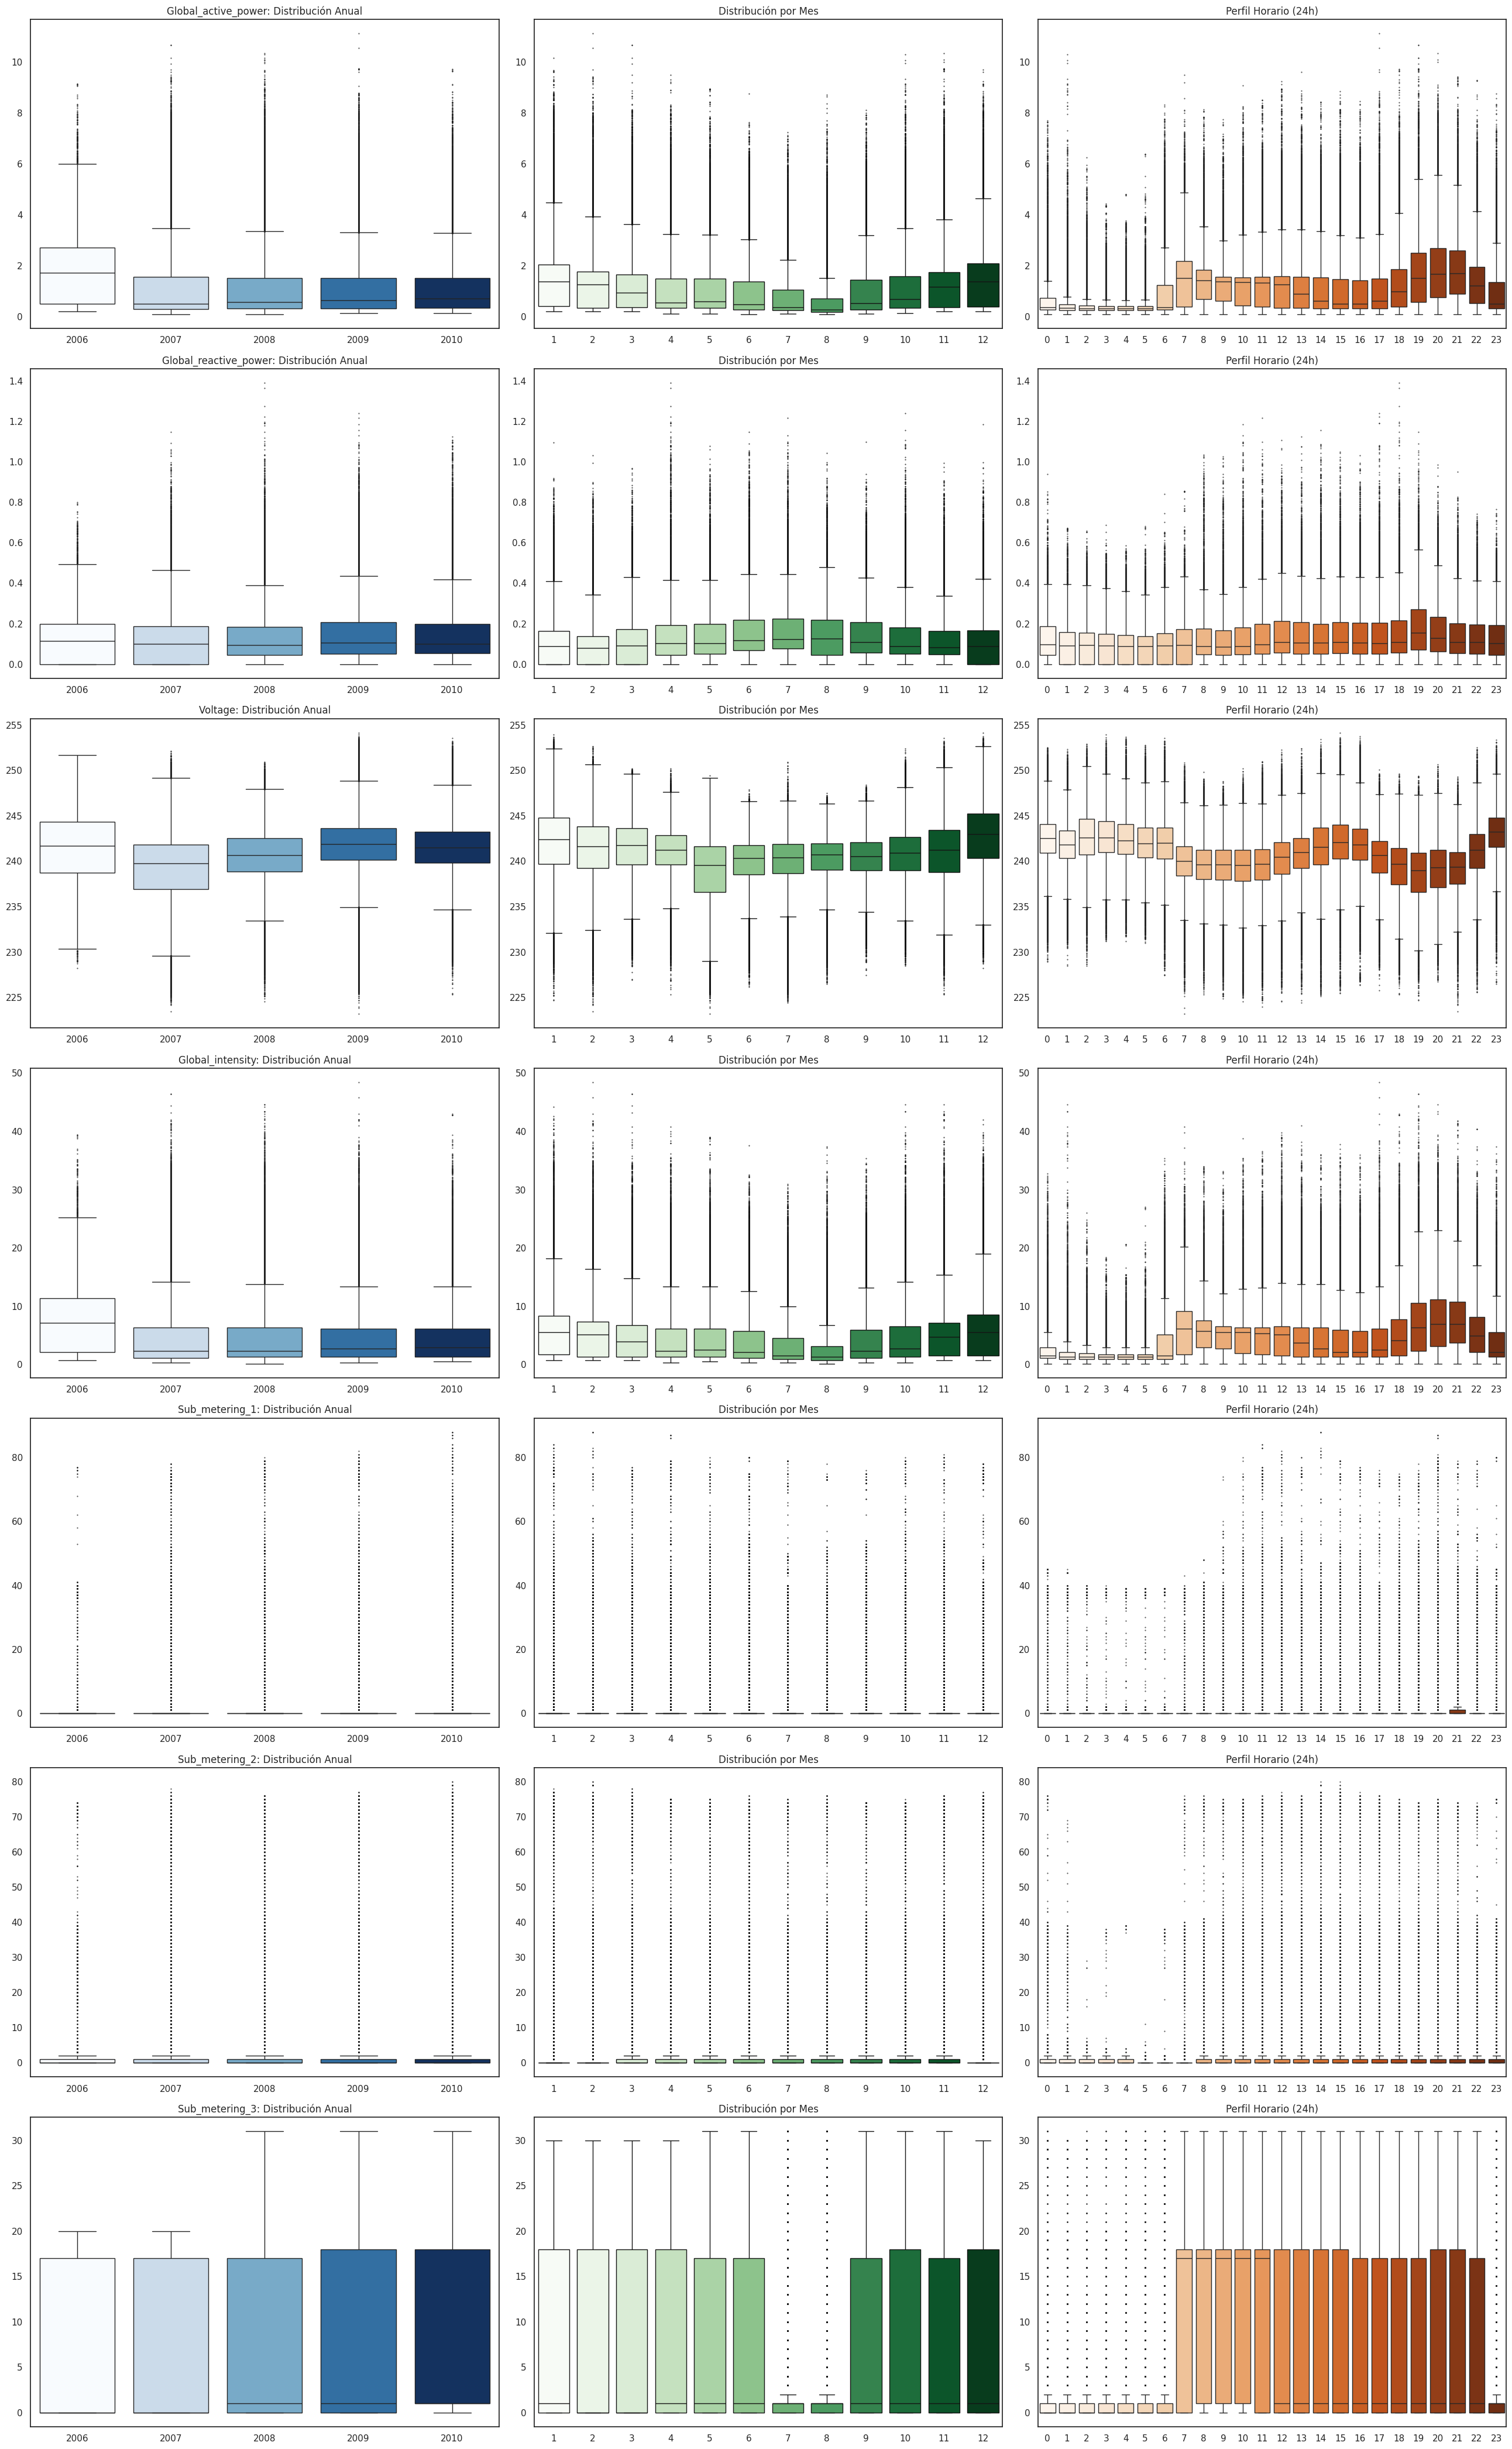

In [40]:
# 1. Asegurar columnas temporales
df_plot = df.with_columns(
    year_month = pl.col("year").cast(pl.String) + "_" + pl.col("month").cast(pl.String).str.pad_start(2, "0")
).sort("date_timestamp")

variables = [c for c in numeric_data_pl.columns if c != "date_timestamp"]

# 3 Columnas: Por Año, Por Mes, Por Hora (Perfil diario)
fig, axes = plt.subplots(nrows=len(variables), ncols=3, figsize=(26, 6 * len(variables)))

for i, var in enumerate(variables):
    y_data = df_plot[var].to_numpy()
    
    # --- BOXPLOT POR AÑO ---
    sns.boxplot(
        x=df_plot["year"].to_numpy(),
        y=y_data,
        ax=axes[i, 0],
        palette="Blues",
        fliersize=0.5,
        hue=df_plot["year"].to_numpy(),
        legend=False
    )
    axes[i, 0].set_title(f"{var}: Distribución Anual")
    
    # --- BOXPLOT POR MES ---
    sns.boxplot(
        x=df_plot["month"].to_numpy(),
        y=y_data,
        ax=axes[i, 1],
        palette="Greens",
        fliersize=0.5,
        hue=df_plot["month"].to_numpy(),
        legend=False
    )
    axes[i, 1].set_title(f"Distribución por Mes")
    
    # --- BOXPLOT POR HORA (Perfil Diario) ---
    sns.boxplot(
        x=df_plot["hour"].to_numpy(),
        y=y_data,
        ax=axes[i, 2],
        palette="Oranges",
        fliersize=0.5,
        hue=df_plot["hour"].to_numpy(),
        legend=False
    )
    axes[i, 2].set_title(f"Perfil Horario (24h)")

plt.tight_layout()
plt.show()

## ⏱️ Evenly spaced?

In [41]:
unique_intervals = df.select(pl.col("date_timestamp").diff()).slice(1).unique()

is_even = unique_intervals.height == 1

if is_even:
    print(f":D Distribución uniforme: {unique_intervals[0,0]}ms")
else:
    print(":c Distribución irregular. Intervalos detectados:")
    print(unique_intervals)

:D Distribución uniforme: 60ms


## 💨 Autocorrelation?

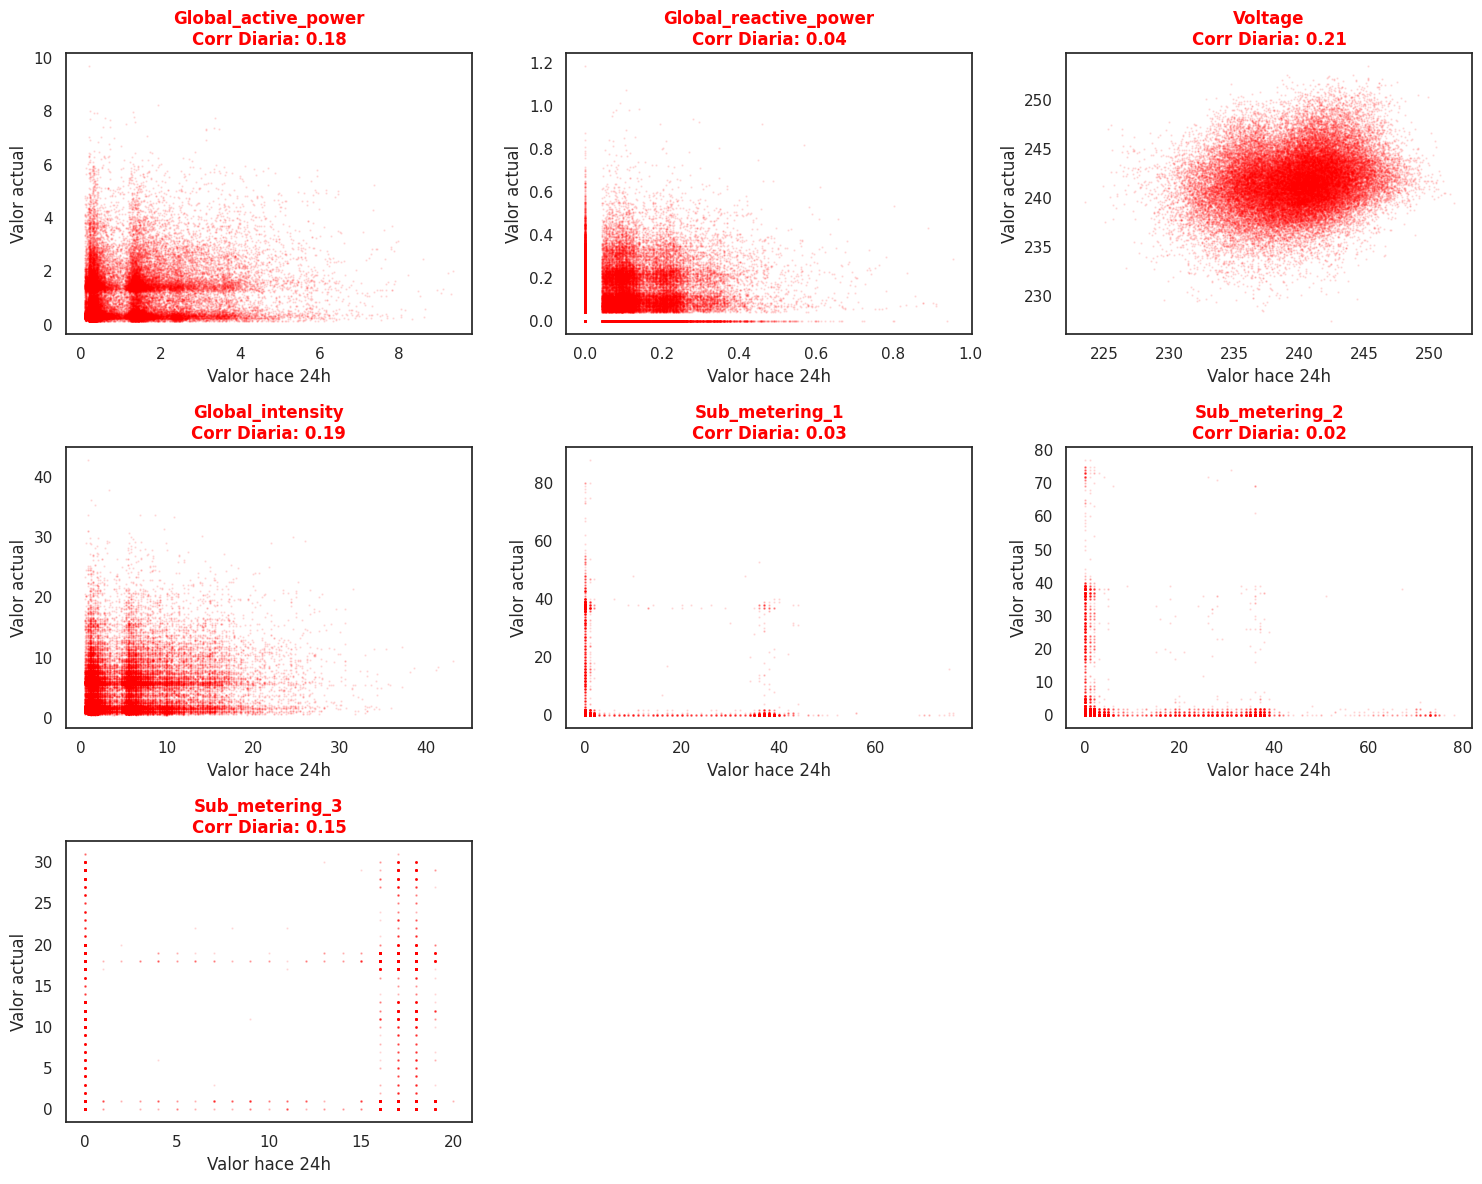

In [42]:
# 1. Calcular el salto exacto para 24 horas
LAG_DIA = (24 * 60 * 60 * 1000) // 60 

n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

threshold = 0.5 

for i, col_name in enumerate(num_cols):
    # Usamos un shift dinámico basado en nuestra frecuencia
    data = df.select([
        pl.col(col_name).alias("y_t"),
        pl.col(col_name).shift(LAG_DIA).alias("y_t_diario")
    ]).drop_nulls()
    
    # Si el dataset es gigante, tomamos una muestra para el plot
    # para que no colapse la memoria del gráfico
    if data.height > 50000:
        plot_data = data.sample(n=50000)
    else:
        plot_data = data

    corr_lag = np.corrcoef(data["y_t"], data["y_t_diario"])[0, 1]
    color = "green" if abs(corr_lag) > threshold else "red"
    
    axes[i].scatter(plot_data["y_t_diario"], plot_data["y_t"], alpha=0.1, s=0.5, c=color)
    axes[i].set_title(f"{col_name}\nCorr Diaria: {corr_lag:.2f}", color=color, fontweight='bold')
    axes[i].set_xlabel("Valor hace 24h")
    axes[i].set_ylabel("Valor actual")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 🧑‍🏭 Solucionar problemas

## 🪡 Imputacion de valores perdidos
### Imputacion spline

In [59]:
from scipy.interpolate import interp1d

# 1. Definimos la referencia temporal (X) y las columnas a imputar
# Usamos el timestamp como eje X para la interpolación
x_full = df.select(pl.col("date_timestamp").dt.timestamp()).to_numpy().flatten()

# 2. Función para interpolar una sola columna
def interpolate_column(col_name):
    y_values = df[col_name].to_numpy()
    # Máscara de valores no nulos
    mask = ~np.isnan(y_values)
    
    # Si no hay suficientes puntos para interpolar, devolvemos la columna original
    if mask.sum() < 2:
        return pl.Series(col_name, y_values)
    
    # Creamos la función de interpolación (kind='linear' o 'cubic')
    f = interp1d(x_full[mask], y_values[mask], kind='linear', fill_value="extrapolate")
    
    # Retornamos la columna completa con los huecos rellenos
    return pl.Series(col_name, f(x_full))

# 3. Aplicamos la interpolación a todas las columnas numéricas "in-place"
df = df.with_columns([
    interpolate_column(col) for col in num_cols
])

## 🏙️ Estandarización  Z-score


In [60]:
# Aplicamos la transformación Z-score "in-place"
# Fórmula: (x - media) / desviación_estándar
print(num_cols)
df = df.with_columns([
    ((pl.col(col) - pl.col(col).mean()) / pl.col(col).std()).alias(col)
    for col in num_cols
])


print(df.describe())

['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']


shape: (9, 9)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ statistic ┆ Global_ac ┆ Global_re ┆ Voltage   ┆ … ┆ Sub_meter ┆ Sub_meter ┆ Sub_meter ┆ date_tim │
│ ---       ┆ tive_powe ┆ active_po ┆ ---       ┆   ┆ ing_1     ┆ ing_2     ┆ ing_3     ┆ estamp   │
│ str       ┆ r         ┆ wer       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│           ┆ ---       ┆ ---       ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
│           ┆ f64       ┆ f64       ┆           ┆   ┆           ┆           ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ count     ┆ 2.075259e ┆ 2.075259e ┆ 2.075259e ┆ … ┆ 2.075259e ┆ 2.075259e ┆ 2.075259e ┆ 2.075259 │
│           ┆ 6         ┆ 6         ┆ 6         ┆   ┆ 6         ┆ 6         ┆ 6         ┆ e6       │
│ null_coun ┆ 0.0       ┆ 0.0       ┆ 0.0       ┆ … ┆ 0.0       ┆ 0.0       ┆

## 🧲 Correlacion

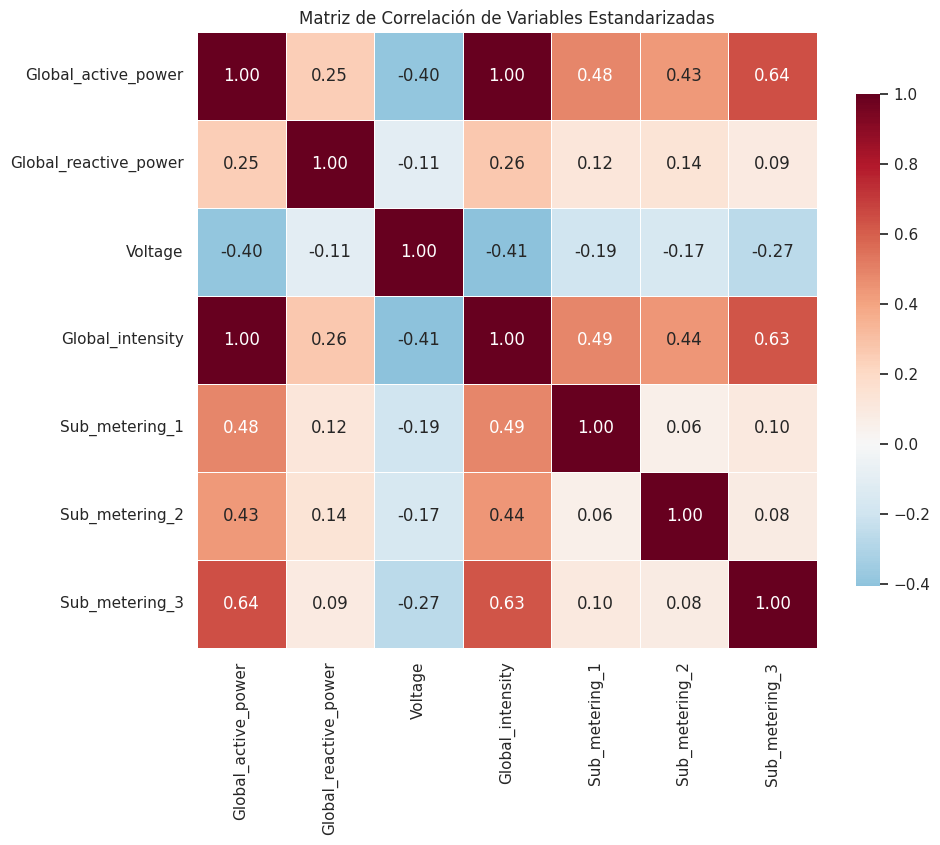

In [61]:
df_corr = df.select(num_cols).to_pandas().corr()

plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

sns.heatmap(
    df_corr, 
    annot=True,           # Muestra los valores numéricos
    fmt=".2f",            # Dos decimales
    cmap="RdBu_r",        # Mapa de color (Rojo para negativo, Azul para positivo)
    center=0,             # El blanco representa correlación nula
    linewidths=.5, 
    cbar_kws={"shrink": .8}
)

plt.title("Matriz de Correlación de Variables Estandarizadas")
plt.show()

## 💤 ADF: Stationarity?

In [ ]:
from statsmodels.tsa.stattools import adfuller
import random

# 1. Parámetros de la simulación
n_total = len(df)
min_size = int(n_total * 0.01)  # Al menos 5% de las filas
num_segments = random.randint(1, 3)  # Número aleatorio de segmentos (ej. entre 3 y 7)
target_col = num_cols[0]  # Realizamos el test sobre la primera columna numérica

print(f"{'='*60}")
print(f"PRUEBA DE DICKEY-FULLER AUMENTADA (ADF)")
print(f"Variable analizada: {target_col}")
print(f"Tamaño total de la muestra: {n_total}")
print(f"Número de segmentos aleatorios evaluados: {num_segments}")
print(f"{'='*60}\n")

# 2. Ejecución de los tests
for i in range(num_segments):
    # Generar rango aleatorio (mínimo 5%, máximo el resto disponible)
    length = random.randint(min_size, n_total)
    # Generar inicio aleatorio que permita el largo elegido
    start = random.randint(0, n_total - length)
    end = start + length
    
    # Extraer segmento
    segment_data = df.slice(start, length)[target_col].to_numpy()
    
    # Ejecutar ADF
    # 'ct' indica constante y tendencia temporal
    result = adfuller(segment_data, autolag='AIC')
    
    p_value = result[1]
    test_stat = result[0]
    crit_values = result[4]
    
    # Print 
    print(f"SEGMENTO {i+1}: [Índice {start} a {end}] (N={length})")
    print(f"  - Estadístico ADF: {test_stat:.4f}")
    print(f"  - p-valor: {p_value:.4e}")
    
    status = "RECHAZADA (Estacionaria)" if p_value < 0.05 else "NO RECHAZADA (No Estacionaria)"
    print(f"  - Hipótesis Nula (H0): {status}")
    print(f"  - Valores Críticos:")
    for key, val in crit_values.items():
        print(f"      {key}: {val:.3f}")
    print("-" * 40)

PRUEBA DE DICKEY-FULLER AUMENTADA (ADF)
Variable analizada: Global_active_power
Tamaño total de la muestra: 2075259
Número de segmentos aleatorios evaluados: 1



KeyboardInterrupt: 

# 📬️ Export data

In [ ]:
# 1. Asegurarnos de que esté ordenado)
df = df.sort("date_timestamp")

# 2. Definir la ventana en unidades enteras
# 5 minutos = 300,000 ms
intervalo_ms = 300000

df_resultado = df.group_by_dynamic(
    "date_timestamp",
    every=f"{intervalo_ms}i"  # Usamos 'i' para indicar unidades enteras
).agg(
    pl.all().exclude("date_timestamp").mean()
)

# 3. Exportar
df_resultado.write_csv("../data/houshold_consumption_rolled.csv")

In [67]:
# Conteo de rows
n_final = df_resultado.height
print(f"Filas resultantes: {n_final}")

# El número de filas esperadas es (Rango Total de Tiempo / Tamaño de Ventana)
rango_tiempo = df["date_timestamp"].max() - df["date_timestamp"].min()
n_esperado = (rango_tiempo / intervalo_ms) + 1

print(f"Filas esperadas (aprox): {int(n_esperado)}")

Filas resultantes: 416
Filas esperadas (aprox): 416
